# Phase 3 — Supply as a Cyclical Risk Amplifier

**Objective**: Determine whether supply behaves as a simple filter or an amplifier under fragile affordability regimes.

**Phase 3 claim (what we test):**
- Regime is a persistent structural state (not threshold noise).
- Supply pressure amplifies downside risk **only** in fragile affordability states.
- Evidence is shown via:
  1) regime persistence,
  2) discrete quadrant outcomes (regime × supply_high),
  3) continuous interaction regression (DTI × months_supply).


## Data

- Panel: `phase3_panel_wret_regime_alt.csv`
  - Includes: `date`, `dti`, `regime`, `months_supply`, `permits`, `starts`, `ret_1q_fwd`, plus alternative regime variants.

- We merge `supply_high` from Phase 2 series for comparability with prior gating results.

**Note on missing forward return**: the final quarter may have `ret_1q_fwd = NaN` (no next quarter data), so performance analyses drop those rows.

In [19]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# HARDCODE project root (stable > clever)
PROJECT_ROOT = Path("/Users/axl/Mispricing Model_Leviathan/leviathan-model")

assert PROJECT_ROOT.exists(), f"PROJECT_ROOT not found: {PROJECT_ROOT}"
os.chdir(PROJECT_ROOT)
print("cwd:", Path.cwd())

PHASE3_PANEL  = Path("data/processed/phase3_panel_wret_regime_alt.csv")
PHASE2_SERIES = Path("outputs/phase2/phase2_strategy_series.csv")

assert PHASE3_PANEL.exists(), f"Missing file: {PHASE3_PANEL}"
assert PHASE2_SERIES.exists(), f"Missing file: {PHASE2_SERIES}"

OUT_TABLE_DIR = Path("outputs/phase3/tables")
OUT_FIG_DIR   = Path("outputs/phase3/figures")
OUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

print("Found:", PHASE3_PANEL)
print("Found:", PHASE2_SERIES)

cwd: /Users/axl/Mispricing Model_Leviathan/leviathan-model
Found: data/processed/phase3_panel_wret_regime_alt.csv
Found: outputs/phase2/phase2_strategy_series.csv


In [20]:
df = pd.read_csv(PHASE3_PANEL)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# merge supply_high (keep Phase 2 comparability)
p2 = pd.read_csv(PHASE2_SERIES, usecols=["date", "supply_high"])
p2["date"] = pd.to_datetime(p2["date"])

df = df.merge(p2, on="date", how="left")

# drop NaN forward returns for any performance/regression
n_missing_ret = df["ret_1q_fwd"].isna().sum()
df_ret = df.dropna(subset=["ret_1q_fwd"]).copy()

print("df shape:", df.shape)
print("df_ret shape:", df_ret.shape)
print("Dropped rows due to missing ret_1q_fwd:", n_missing_ret)
df_ret.head(3)


df shape: (104, 14)
df_ret shape: (103, 14)
Dropped rows due to missing ret_1q_fwd: 1


,date,dti,real_rate,regime,real_price_index,permits,starts,months_supply,ret_1q_fwd,dti_roll_pctl,dti_roll_z,regime_pctl70,regime_z05,supply_high
0,1999-03-31,83.132765,0.182830,0,100.000000,1705.666667,1709.333333,4.000000,0.008659,NaN,NaN,0,0,0
1,1999-06-30,91.074562,-0.261601,1,100.869636,1647.333333,1574.333333,3.933333,0.017159,NaN,NaN,0,0,0
2,1999-09-30,84.070830,1.153580,0,102.615396,1634.666667,1650.666667,4.166667,-0.005264,NaN,NaN,0,0,0


## Module A — Regime stability (persistence)

We verify regime is not threshold noise by checking transition probabilities:
- \( P(regime_t \mid regime_{t-1}) \)
- \( P(regime_t \mid regime_{t-2}) \)

High persistence supports interpreting regime as a structural state.


In [21]:
df_tmp = df.copy()
df_tmp["regime_lag1"] = df_tmp["regime"].shift(1)
df_tmp["regime_lag2"] = df_tmp["regime"].shift(2)

tab1 = pd.crosstab(df_tmp["regime"], df_tmp["regime_lag1"], normalize="index")
tab2 = pd.crosstab(df_tmp["regime"], df_tmp["regime_lag2"], normalize="index")

display(tab1)
display(tab2)

tab1.to_csv(OUT_TABLE_DIR / "regime_persistence_t_vs_t-1.csv")
tab2.to_csv(OUT_TABLE_DIR / "regime_persistence_t_vs_t-2.csv")

print("saved:",
      OUT_TABLE_DIR / "regime_persistence_t_vs_t-1.csv",
      OUT_TABLE_DIR / "regime_persistence_t_vs_t-2.csv")


regime_lag1,0.0,1.0
regime,,
0,0.854545,0.145455
1,0.166667,0.833333


regime_lag2,0.0,1.0
regime,,
0,0.854545,0.145455
1,0.170213,0.829787


saved: outputs/phase3/tables/regime_persistence_t_vs_t-1.csv outputs/phase3/tables/regime_persistence_t_vs_t-2.csv


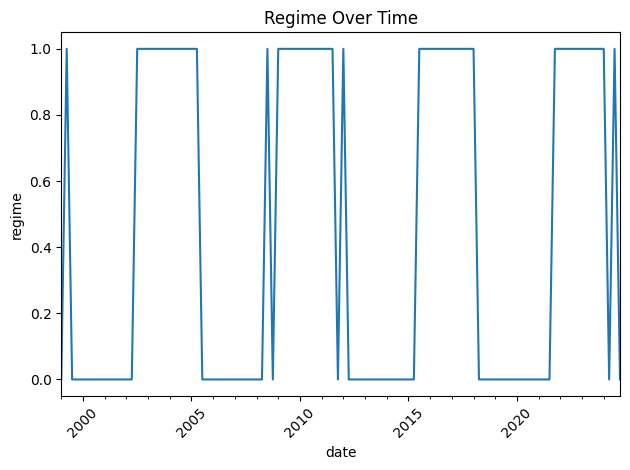

saved: outputs/phase3/figures/regime_over_time.png


In [22]:
s = df.set_index("date")["regime"].astype(float)
ax = s.plot()
plt.title("Regime Over Time")
plt.xlabel("date")
plt.ylabel("regime")
plt.xticks(rotation=45)
plt.tight_layout()

fig_path = OUT_FIG_DIR / "regime_over_time.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("saved:", fig_path)


## Note on rolling percentile mean (~0.91)

`dti_roll_pctl` is computed as the **percentile rank of current DTI within a rolling window** (40 quarters).
Because DTI trends upward over the sample, the "current" observation is often near the top of its trailing-window distribution, so the average percentile rank can be high.

We use the rolling percentile as a **relative stress gauge**, not as a symmetric variable expected to average around 0.5.


## Module B — Discrete evidence (regime × supply_high)

We summarize outcomes by 4 quadrants:
- regime ∈ {0,1}
- supply_high ∈ {0,1}

Key quantities:
- mean return
- left-tail (p05)
- volatility
- sample size (n)

If supply is an **amplifier**, we expect regime 0 + supply_high to show materially worse left-tail outcomes.


In [31]:
quad_path = OUT_TABLE_DIR / "quadrant_regime_supply.csv"

if not quad_path.exists():
    grp = df_ret.groupby(["regime", "supply_high"])["ret_1q_fwd"]
    quad = grp.agg([
        ("mean_ret", "mean"),
        ("p05", lambda x: np.percentile(x, 5)),
        ("vol", "std"),
        ("n", "count"),
    ]).reset_index()

    quad.to_csv(quad_path, index=False)
    print("Generated quadrant table:", quad_path)
else:
    quad = pd.read_csv(quad_path)
    print("Loaded existing quadrant table:", quad_path)

quad = quad.sort_values(["regime", "supply_high"]).reset_index(drop=True)
display(quad)

(OUT_TABLE_DIR / "quadrant_regime_supply_sorted.csv").write_text(quad.to_csv(index=False))

# ---- add: sample size note (pre-empt reviewer pushback) ----
min_n = int(quad["n"].min())
print(f"Quadrant sample sizes (min n = {min_n}). Interpret tail estimates with this context.")

Loaded existing quadrant table: outputs/phase3/tables/quadrant_regime_supply.csv


,regime,supply_high,mean_ret,p05,vol,n
0,0,0,0.009612,-0.000123,0.007566,38
1,0,1,-0.014505,-0.047252,0.027240,17
2,1,0,0.011056,-0.004708,0.011078,28
3,1,1,0.013808,0.000688,0.009382,20


Quadrant sample sizes (min n = 17). Interpret tail estimates with this context.


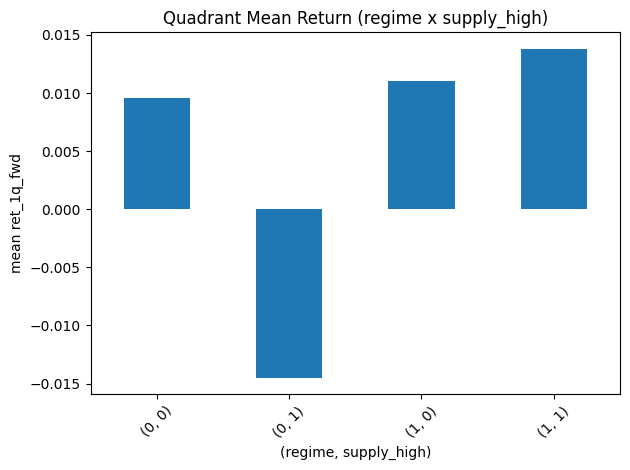

saved: outputs/phase3/figures/quadrant_mean.png


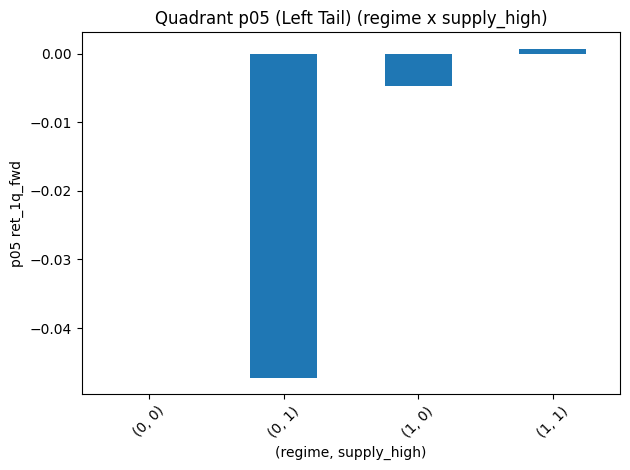

saved: outputs/phase3/figures/quadrant_p05.png


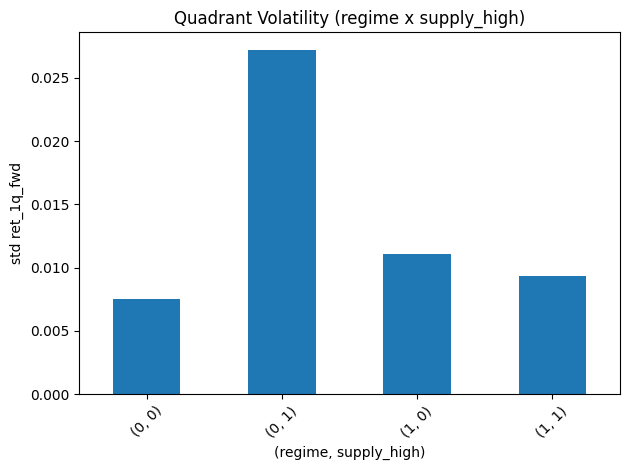

saved: outputs/phase3/figures/quadrant_vol.png


In [25]:
quad_idx = quad.set_index(["regime", "supply_high"])

# mean
ax = quad_idx["mean_ret"].plot(kind="bar")
plt.title("Quadrant Mean Return (regime x supply_high)")
plt.xlabel("(regime, supply_high)")
plt.ylabel("mean ret_1q_fwd")
plt.xticks(rotation=45)
plt.tight_layout()
p = OUT_FIG_DIR / "quadrant_mean.png"
plt.savefig(p, dpi=200)
plt.show()
print("saved:", p)

# p05
ax = quad_idx["p05"].plot(kind="bar")
plt.title("Quadrant p05 (Left Tail) (regime x supply_high)")
plt.xlabel("(regime, supply_high)")
plt.ylabel("p05 ret_1q_fwd")
plt.xticks(rotation=45)
plt.tight_layout()
p = OUT_FIG_DIR / "quadrant_p05.png"
plt.savefig(p, dpi=200)
plt.show()
print("saved:", p)

# vol
ax = quad_idx["vol"].plot(kind="bar")
plt.title("Quadrant Volatility (regime x supply_high)")
plt.xlabel("(regime, supply_high)")
plt.ylabel("std ret_1q_fwd")
plt.xticks(rotation=45)
plt.tight_layout()
p = OUT_FIG_DIR / "quadrant_vol.png"
plt.savefig(p, dpi=200)
plt.show()
print("saved:", p)


## Module B — Continuous interaction test

We test whether supply impact is state-dependent using a simple interaction model:

\[
ret\_{t+1} = \alpha + \beta\_1 \cdot dti + \beta\_2 \cdot months\_supply + \beta\_3 \cdot (dti \times months\_supply) + \epsilon
\]

Because raw-scale interaction can create numerical conditioning issues, we also run a **z-score standardized** version:
- `dti_z`, `ms_z`, and `dti_z * ms_z`

If supply is an amplifier in fragile states, the interaction term should be meaningful and directionally consistent.


In [33]:
import statsmodels.api as sm

reg = df_ret[["ret_1q_fwd", "dti", "months_supply"]].dropna().copy()

# z-score standardization
reg["dti_z"] = (reg["dti"] - reg["dti"].mean()) / reg["dti"].std(ddof=0)
reg["ms_z"]  = (reg["months_supply"] - reg["months_supply"].mean()) / reg["months_supply"].std(ddof=0)
reg["interaction_z"] = reg["dti_z"] * reg["ms_z"]

X = sm.add_constant(reg[["dti_z", "ms_z", "interaction_z"]])
y = reg["ret_1q_fwd"]

# 1) vanilla OLS
mz = sm.OLS(y, X).fit()

# 2) HAC / Newey-West (quarterly data: start with 4 lags)
mz_hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

print("=== OLS (nonrobust) ===")
print(mz.summary())

print("\n=== OLS + Newey-West HAC (maxlags=4) ===")
print(mz_hac.summary())

# Save both summaries
txtz = OUT_TABLE_DIR / "interaction_regression_zscore.txt"
txtz.write_text(mz.summary().as_text())

txtz_hac = OUT_TABLE_DIR / "interaction_regression_zscore_hac4.txt"
txtz_hac.write_text(mz_hac.summary().as_text())

print("saved:", txtz)
print("saved:", txtz_hac)


=== OLS (nonrobust) ===
                            OLS Regression Results                            
Dep. Variable:             ret_1q_fwd   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     7.530
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           0.000137
Time:                        21:43:54   Log-Likelihood:                 286.38
No. Observations:                 103   AIC:                            -564.8
Df Residuals:                      99   BIC:                            -554.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.00

## Phase 3 conclusion

**Evidence suggests supply acts as a state-dependent amplifier** under fragile affordability states (regime 0):
- Discrete quadrant outcomes show materially worse mean and left-tail (p05) only in **regime 0 × supply_high**.
- Continuous interaction regression finds a statistically significant interaction between affordability stress (DTI) and supply pressure (months_supply).

This is **statistical evidence of state-dependence**, not a causal identification claim.



In [34]:
q = quad.set_index(["regime", "supply_high"])
r0_low = q.loc[(0, 0)]
r0_high = q.loc[(0, 1)]

one_liner = (
    f"Key result: In regime 0, supply_high shifts mean return from {r0_low['mean_ret']:.4f} to {r0_high['mean_ret']:.4f} "
    f"and worsens p05 from {r0_low['p05']:.4f} to {r0_high['p05']:.4f}. "
    f"This pattern is consistent with supply acting as a state-dependent risk amplifier under fragile affordability conditions."
)

conclusions = [
    "Regime is persistent (high t vs t-1 / t-2 stability), supporting a structural state interpretation.",
    "Quadrant evidence: regime0 + supply_high shows materially worse mean and left-tail (p05) outcomes.",
    "Continuous test: the DTI × months_supply interaction remains statistically significant under Newey-West HAC(4), consistent with state-dependent amplification."
]

print(one_liner)
for c in conclusions:
    print("- " + c)

(OUT_TABLE_DIR / "phase3_one_liner.txt").write_text(one_liner + "\n")
(OUT_TABLE_DIR / "phase3_conclusions.txt").write_text("\n".join("- " + c for c in conclusions) + "\n")

print("saved:", OUT_TABLE_DIR / "phase3_one_liner.txt")
print("saved:", OUT_TABLE_DIR / "phase3_conclusions.txt")

Key result: In regime 0, supply_high shifts mean return from 0.0096 to -0.0145 and worsens p05 from -0.0001 to -0.0473. This pattern is consistent with supply acting as a state-dependent risk amplifier under fragile affordability conditions.
- Regime is persistent (high t vs t-1 / t-2 stability), supporting a structural state interpretation.
- Quadrant evidence: regime0 + supply_high shows materially worse mean and left-tail (p05) outcomes.
- Continuous test: the DTI × months_supply interaction remains statistically significant under Newey-West HAC(4), consistent with state-dependent amplification.
saved: outputs/phase3/tables/phase3_one_liner.txt
saved: outputs/phase3/tables/phase3_conclusions.txt
